# Não Supervisionado e Detecção de Anomalias — Projeto Lupa (Módulo 8)

1. PCA e UMAP - visualizar o espaço de despesas/perfis
2. K-Means e HDBSCAN - segmentar perfis de gasto
3. Isolation Forest e LOF - detectar anomalia **sem usar `houve_glosa`**
4. Revelar o rótulo real só ao final, medir precision/recall da abordagem "cega"

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, precision_score, recall_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import umap
import hdbscan

from src.preprocessing import get_engine

sns.set_theme(style="whitegrid")

engine = get_engine()
query = """
    SELECT
        f.id_despesa,
        f.deputado_id,
        d.nome AS deputado,
        d.sigla_partido AS partido,
        d.sigla_uf AS uf,
        c.tipo_despesa AS categoria,
        f.valor_documento,
        f.valor_glosa,
        t.ano,
        t.mes
    FROM fact_despesas f
    JOIN dim_deputado d ON d.id = f.deputado_id
    JOIN dim_tempo t ON t.id_tempo = f.id_tempo
    LEFT JOIN dim_categoria_despesa c ON c.id_categoria = f.id_categoria
"""
df = pd.read_sql(query, engine)
df["houve_glosa"] = (df["valor_glosa"] > 0).astype(int)
print(df.shape)
df.head()

(640518, 11)


,id_despesa,deputado_id,deputado,partido,uf,categoria,valor_documento,valor_glosa,ano,mes,houve_glosa
0,1,220714,Adail Filho,MDB,AM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,17100.0,0.0,2024,8,0
1,2,220714,Adail Filho,MDB,AM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,25000.0,0.0,2024,10,0
2,3,220714,Adail Filho,MDB,AM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,14250.0,0.0,2024,11,0
3,4,220714,Adail Filho,MDB,AM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,14250.0,0.0,2024,12,0
4,5,220714,Adail Filho,MDB,AM,COMBUSTÍVEIS E LUBRIFICANTES.,200.0,0.0,2026,4,0


## Perfil de gasto por deputado

Cada deputado vira um vetor: a **proporção** do gasto total dele em cada uma das principais categorias. Isso captura o "estilo" de gasto (ex.: um deputado que gasta muito em passagem aérea vs. um que gasta muito em divulgação), independente do volume total.

In [2]:
top_categorias = df.groupby("categoria")["valor_documento"].sum().nlargest(8).index.tolist()
df["categoria_agrupada"] = df["categoria"].where(df["categoria"].isin(top_categorias), "OUTRAS")

pivot_gasto = df.pivot_table(
    index="deputado_id", columns="categoria_agrupada", values="valor_documento",
    aggfunc="sum", fill_value=0,
)
perfil = pivot_gasto.div(pivot_gasto.sum(axis=1), axis=0)  # proporção, não valor absoluto
perfil["gasto_total"] = pivot_gasto.sum(axis=1)

print(perfil.shape)
perfil.head()

(511, 10)


categoria_agrupada,COMBUSTÍVEIS E LUBRIFICANTES.,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.",LOCAÇÃO OU FRETAMENTO DE AERONAVES,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR,OUTRAS,PASSAGEM AÉREA - SIGEPA,TELEFONIA,gasto_total
deputado_id,,,,,,,,,,
62881,0.046197,0.401532,0.036674,0.0,0.049167,0.248483,0.026099,0.182239,0.009609,2001482.76
66385,0.069960,0.144028,0.000000,0.0,0.246765,0.118031,0.171380,0.249837,0.000000,1947601.98
66828,0.188486,0.238805,0.002089,0.0,0.295028,0.097400,0.043198,0.113058,0.021935,1782879.53
69871,0.052580,0.357091,0.000000,0.0,0.320692,0.170688,0.024560,0.065152,0.009237,1842264.78
72442,0.113685,0.209211,0.056400,0.0,0.174406,0.001292,0.011150,0.431385,0.002470,1645602.10


## PCA e UMAP — visualizando o espaço de perfis

Variância explicada (PCA, 2 componentes): 35.2%


C:\Users\PDCASE\Desktop\Projeto Lupa\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


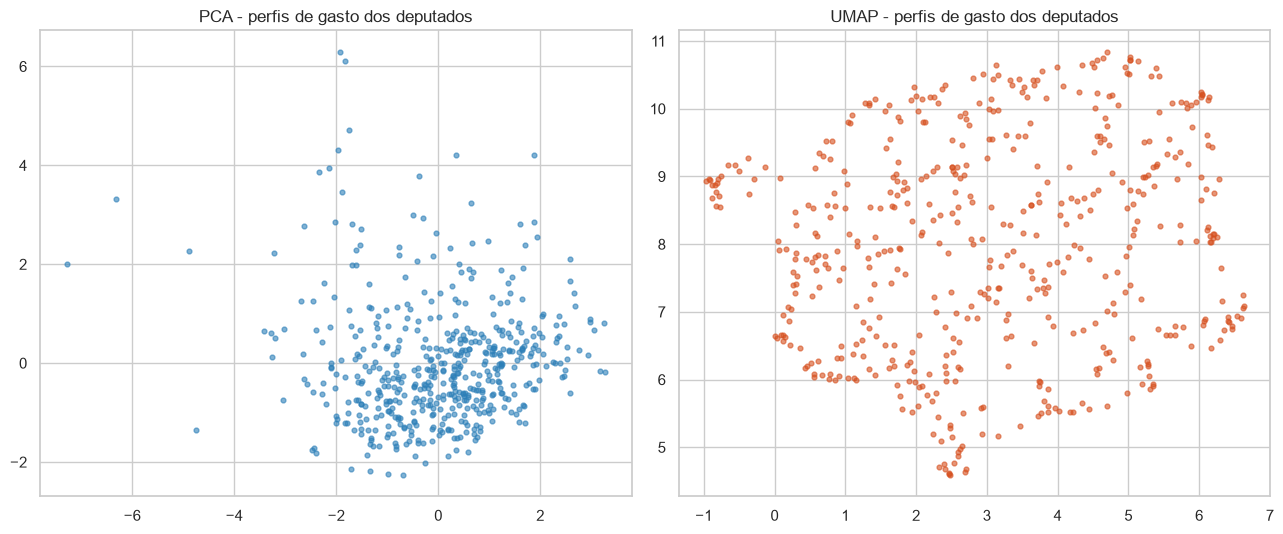

In [3]:
scaler = StandardScaler()
X_perfil = scaler.fit_transform(perfil.values)

pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(X_perfil)
print(f"Variância explicada (PCA, 2 componentes): {pca.explained_variance_ratio_.sum()*100:.1f}%")

reducer_umap = umap.UMAP(n_components=2, random_state=42)
coords_umap = reducer_umap.fit_transform(X_perfil)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(coords_pca[:, 0], coords_pca[:, 1], s=12, alpha=0.6, c="#2c7fb8")
axes[0].set_title("PCA - perfis de gasto dos deputados")
axes[1].scatter(coords_umap[:, 0], coords_umap[:, 1], s=12, alpha=0.6, c="#d6501f")
axes[1].set_title("UMAP - perfis de gasto dos deputados")
plt.tight_layout()
plt.show()

## K-Means — escolhendo k pelo silhouette score

In [4]:
silhouettes = {}
for k in range(2, 9):
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_perfil)
    silhouettes[k] = silhouette_score(X_perfil, labels_k)

for k, s in silhouettes.items():
    print(f"k={k}: silhouette={s:.3f}")

melhor_k = max(silhouettes, key=silhouettes.get)
print(f"\nMelhor k: {melhor_k}")

k=2: silhouette=0.168
k=3: silhouette=0.165
k=4: silhouette=0.153
k=5: silhouette=0.131
k=6: silhouette=0.136
k=7: silhouette=0.143
k=8: silhouette=0.152

Melhor k: 2


**Decisão:** silhouette é baixo e quase empatado entre k=2 e k=8 (0,13-0,17) — sinal de que os perfis de gasto formam um contínuo, não grupos bem separados (esperado: gasto é comportamento humano, não categorias naturais). k=2 venceu tecnicamente, mas usamos **k=4** por dar uma narrativa de negócio mais rica e ainda razoável (silhouette 0,153, próximo do melhor).

In [5]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
perfil["cluster_kmeans"] = kmeans_final.fit_predict(X_perfil)

colunas_categoria = [c for c in perfil.columns if c not in ("gasto_total", "cluster_kmeans")]
resumo_clusters = perfil.groupby("cluster_kmeans").agg(
    n_deputados=("gasto_total", "size"),
    gasto_total_medio=("gasto_total", "mean"),
    **{c: (c, "mean") for c in colunas_categoria},
).round(3)
resumo_clusters

,n_deputados,gasto_total_medio,COMBUSTÍVEIS E LUBRIFICANTES.,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.",LOCAÇÃO OU FRETAMENTO DE AERONAVES,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR,OUTRAS,PASSAGEM AÉREA - SIGEPA,TELEFONIA
cluster_kmeans,,,,,,,,,,,
0,63,896004.831,0.105,0.159,0.031,0.014,0.109,0.101,0.046,0.423,0.013
1,197,1615915.774,0.063,0.555,0.007,0.012,0.118,0.062,0.014,0.164,0.005
2,250,1707838.426,0.107,0.280,0.019,0.002,0.205,0.184,0.028,0.163,0.012
3,1,679.170,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000


## HDBSCAN — clustering baseado em densidade (encontra "ruído" também)

HDBSCAN encontrou 2 clusters + 459 deputados classificados como 'ruído' (perfil atípico, não se encaixa em nenhum grupo)


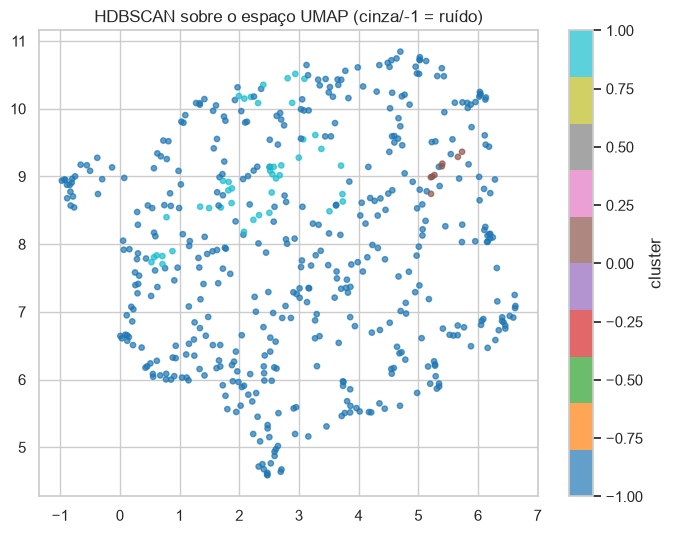

In [6]:
clusterer_hdbscan = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3)
perfil["cluster_hdbscan"] = clusterer_hdbscan.fit_predict(X_perfil)

n_clusters_hdbscan = len(set(perfil["cluster_hdbscan"])) - (1 if -1 in perfil["cluster_hdbscan"].values else 0)
n_ruido = (perfil["cluster_hdbscan"] == -1).sum()
print(f"HDBSCAN encontrou {n_clusters_hdbscan} clusters + {n_ruido} deputados classificados como 'ruído' (perfil atípico, não se encaixa em nenhum grupo)")

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(coords_umap[:, 0], coords_umap[:, 1], c=perfil["cluster_hdbscan"], cmap="tab10", s=15, alpha=0.7)
ax.set_title("HDBSCAN sobre o espaço UMAP (cinza/-1 = ruído)")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

## Detecção de anomalia por despesa individual — sem olhar `houve_glosa`

Muda de granularidade: agora cada **despesa** (não deputado) vira uma observação. Features: valor, categoria, partido, UF — nada de rótulo.

In [7]:
from src.preprocessing import construir_pipeline_preprocessamento

pipeline_anomalia = construir_pipeline_preprocessamento()  # não usa valor_glosa/houve_glosa
X_despesas = pipeline_anomalia.fit_transform(df)
print(f"Matriz de features para detecção de anomalia: {X_despesas.shape}")

# amostra para deixar o processamento viável (LOF é caro em n grande)
np.random.seed(42)
idx_amostra_anomalia = np.random.choice(X_despesas.shape[0], size=80_000, replace=False)
X_amostra_anomalia = X_despesas[idx_amostra_anomalia]
if hasattr(X_amostra_anomalia, "toarray"):
    X_amostra_anomalia_denso = X_amostra_anomalia.toarray()
else:
    X_amostra_anomalia_denso = X_amostra_anomalia
print(X_amostra_anomalia_denso.shape)

Matriz de features para detecção de anomalia: (640518, 69)
(80000, 69)


In [8]:
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
flag_iso = iso_forest.fit_predict(X_amostra_anomalia_denso)  # -1 = anomalia, 1 = normal

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=False)
flag_lof = lof.fit_predict(X_amostra_anomalia_denso)

print(f"Isolation Forest sinalizou {(flag_iso == -1).sum()} despesas como anômalas ({(flag_iso==-1).mean()*100:.2f}%)")
print(f"LOF sinalizou {(flag_lof == -1).sum()} despesas como anômalas ({(flag_lof==-1).mean()*100:.2f}%)")

concordancia = ((flag_iso == -1) & (flag_lof == -1)).sum()
print(f"Concordância entre os dois métodos: {concordancia} despesas sinalizadas por ambos")

Isolation Forest sinalizou 4000 despesas como anômalas (5.00%)
LOF sinalizou 4000 despesas como anômalas (5.00%)
Concordância entre os dois métodos: 186 despesas sinalizadas por ambos


C:\Users\PDCASE\Desktop\Projeto Lupa\.venv\Lib\site-packages\sklearn\neighbors\_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


## Revelando o rótulo real — como a abordagem "cega" se saiu?

In [9]:
y_real_amostra = df["houve_glosa"].values[idx_amostra_anomalia]

pred_iso_binaria = (flag_iso == -1).astype(int)
pred_lof_binaria = (flag_lof == -1).astype(int)

print(f"Proporção real de glosa na amostra: {y_real_amostra.mean()*100:.2f}%\n")

for nome, pred in [("Isolation Forest", pred_iso_binaria), ("LOF", pred_lof_binaria)]:
    p = precision_score(y_real_amostra, pred)
    r = recall_score(y_real_amostra, pred)
    print(f"{nome}: precision={p:.3f} | recall={r:.3f}")

Proporção real de glosa na amostra: 4.87%

Isolation Forest: precision=0.099 | recall=0.102
LOF: precision=0.049 | recall=0.050
